In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())      
print(torch.cuda.get_device_name(0))  

True
2
Tesla T4


In [3]:
!pip install -q bertopic sentence-transformers umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.4 MB/s eta 0:00:00


In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/hashes.txt
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/database.sqlite


In [5]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nScore distribution:\n{df['Score'].value_counts().sort_index()}")
df.head(3)

Shape: (568454, 10)

Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Missing values:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Score distribution:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


In [6]:
# Drop duplicates and nulls
df = df.drop_duplicates(subset='Text')
df = df.dropna(subset=['Text', 'Score'])

# Drop neutral reviews (score 3) 
df = df[df['Score'] != 3].copy()

# Binary label: 1 = positive (4-5 stars), 0 = negative (1-2 stars)
df['label'] = (df['Score'] >= 4).astype(int)

print(f"After cleaning: {df.shape}")
print(f"\nLabel balance:\n{df['label'].value_counts()}")
print(f"\nPositive %: {df['label'].mean()*100:.1f}%")

# Sample 50k rows
df_sample = df.sample(n=50000, random_state=42).reset_index(drop=True)
print(f"\nWorking sample shape: {df_sample.shape}")
df_sample[['Score', 'label', 'Text']].head(5)

After cleaning: (363825, 11)

Label balance:
label
1    306758
0     57067
Name: count, dtype: int64

Positive %: 84.3%

Working sample shape: (50000, 11)


,Score,label,Text
0,1,0,This is my original review:<br />My super pick...
1,5,1,I adore Earl Grey tea.<br /><br />The tin look...
2,2,0,My big puppy is not impressed. He'll ignore a ...
3,5,1,This top shelf stuff is Great. Just add a litt...
4,5,1,"I don't do unsweetened, unsalted, peanut butte..."


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    df_sample['Text'].tolist(),
    df_sample['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_sample['label']  # preserves 84/16 ratio in both splits
)

print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Train positive %:   {sum(y_train)/len(y_train)*100:.1f}%")
print(f"Val positive %:     {sum(y_val)/len(y_val)*100:.1f}%")

Training samples:   40000
Validation samples: 10000
Train positive %:   84.4%
Val positive %:     84.4%


In [8]:
import re
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)       
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text) 
    text = re.sub(r'\s+', ' ', text)        
    return text.strip().lower()

# Apply cleaning
X_train_clean = [clean_text(t) for t in X_train]
X_val_clean   = [clean_text(t) for t in X_val]

# Verify cleaning worked
print("Before:", X_train[0][:150])
print("\nAfter: ", X_train_clean[0][:150])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Before: There isn't much not to like about this bar, except that it seems kind of small for the price.  The chocolate is organic, it's difficult to top that. 

After:  there isn t much not to like about this bar except that it seems kind of small for the price the chocolate is organic it s difficult to top that no gu


In [9]:
train_encodings = tokenizer(
    X_train_clean,
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors='pt'
)

val_encodings = tokenizer(
    X_val_clean,
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors='pt'
)

print(f"Train input_ids shape: {train_encodings['input_ids'].shape}")
print(f"Val input_ids shape:   {val_encodings['input_ids'].shape}")

Train input_ids shape: torch.Size([40000, 256])
Val input_ids shape:   torch.Size([10000, 256])


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = ReviewDataset(train_encodings, y_train)
val_dataset   = ReviewDataset(val_encodings,   y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Train batches: 1250
Val batches:   157


In [11]:
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_scheduler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
model.to(device)

# Class weights to handle 84/16 imbalance
neg_count = y_train.count(0)
pos_count = y_train.count(1)
total     = len(y_train)

weight_for_0 = total / (2 * neg_count)
weight_for_1 = total / (2 * pos_count)
class_weights = torch.tensor([weight_for_0, weight_for_1]).to(device)

print(f"Class weight for negative: {weight_for_0:.3f}")
print(f"Class weight for positive: {weight_for_1:.3f}")

# Optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

num_epochs        = 3
num_training_steps = num_epochs * len(train_loader)

lr_scheduler = get_scheduler(
    'linear',
    optimizer=optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps
)

print(f"\nTotal training steps: {num_training_steps}")

Using device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weight for negative: 3.208
Class weight for positive: 0.592

Total training steps: 3750


In [12]:
import torch.nn as nn
from tqdm import tqdm

loss_fn = nn.CrossEntropyLoss(weight=class_weights)

for epoch in range(num_epochs):
    # Training 
    model.train()
    total_train_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation 
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs    = model(input_ids=input_ids, attention_mask=attention_mask)
            preds      = torch.argmax(outputs.logits, dim=1)
            correct   += (preds == labels).sum().item()
            total     += labels.size(0)

    val_accuracy = correct / total
    print(f"\nEpoch {epoch+1} — Loss: {avg_train_loss:.4f} | Val Accuracy: {val_accuracy*100:.2f}%")

print("\nTraining complete!")

Epoch 1 Training: 100%|██████████| 1250/1250 [13:31<00:00,  1.54it/s]



Epoch 1 — Loss: 0.2783 | Val Accuracy: 93.25%


Epoch 2 Training: 100%|██████████| 1250/1250 [13:36<00:00,  1.53it/s]



Epoch 2 — Loss: 0.1267 | Val Accuracy: 94.90%


Epoch 3 Training: 100%|██████████| 1250/1250 [13:36<00:00,  1.53it/s]



Epoch 3 — Loss: 0.0649 | Val Accuracy: 95.05%

Training complete!


              precision    recall  f1-score   support

    Negative       0.80      0.91      0.85      1559
    Positive       0.98      0.96      0.97      8441

    accuracy                           0.95     10000
   macro avg       0.89      0.93      0.91     10000
weighted avg       0.95      0.95      0.95     10000



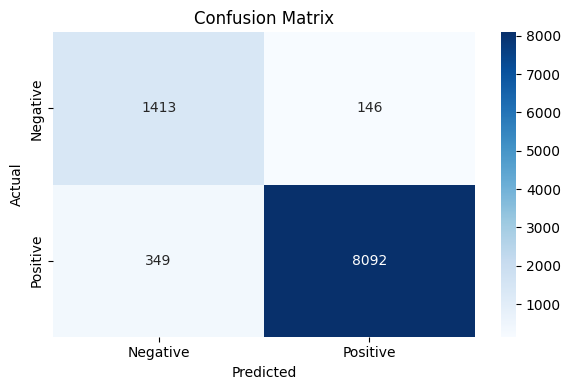

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(
    all_labels, all_preds,
    target_names=['Negative', 'Positive']
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [14]:
model.save_pretrained('/kaggle/working/sentiment_model')
tokenizer.save_pretrained('/kaggle/working/sentiment_model')
print("Model saved to /kaggle/working/sentiment_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /kaggle/working/sentiment_model


In [15]:
from sentence_transformers import SentenceTransformer

# Use a lightweight but strong embedding model
embedder = SentenceTransformer('all-MiniLM-L6-v2')
embedder = embedder.to(device)

# We'll run BERTopic on the full 50k sample text
texts = df_sample['Text'].apply(clean_text).tolist()

print("Generating embeddings... this takes ~5 minutes")
embeddings = embedder.encode(
    texts,
    batch_size=256,
    show_progress_bar=True,
    device='cuda'
)

print(f"\nEmbeddings shape: {embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating embeddings... this takes ~5 minutes


Batches:   0%|          | 0/196 [00:00<?, ?it/s]


Embeddings shape: (50000, 384)


In [16]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

# Configure UMAP and HDBSCAN for reproducibility
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=100,
    min_samples=10,
    metric='euclidean',
    prediction_data=True
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    top_n_words=10,
    verbose=True
)

topics, probs = topic_model.fit_transform(texts, embeddings)

print(f"\nNumber of topics found: {topic_model.nr_topics}")
print(f"Outlier topic (-1) size: {topics.count(-1)}")

2026-05-09 06:14:56.012580: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778307296.410347      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778307296.530064      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778307297.509078      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778307297.509106      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778307297.509108      57 computation_placer.cc:177] computation placer alr


Number of topics found: None
Outlier topic (-1) size: 10305


In [17]:
topic_info = topic_model.get_topic_info()
print(f"Total topics found: {len(topic_info) - 1}")  # minus 1 for outlier topic -1
print(f"Outlier reviews: {topics.count(-1)} out of {len(topics)}")
print(f"\nTop 15 topics:\n")
print(topic_info.head(16).to_string())

Total topics found: 78
Outlier reviews: 10305 out of 50000

Top 15 topics:

    Topic  Count                               Name                                                          Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [18]:
# Show keywords for top 10 topics
for topic_id in topic_info['Topic'].head(11).tolist():
    if topic_id == -1:
        continue
    words = topic_model.get_topic(topic_id)
    keywords = [w[0] for w in words[:7]]
    count = topic_info[topic_info['Topic'] == topic_id]['Count'].values[0]
    print(f"Topic {topic_id:3d} ({count:5d} reviews): {', '.join(keywords)}")

Topic   0 ( 5056 reviews): coffee, cup, the, this, cups, of, it
Topic   1 ( 3949 reviews): tea, teas, it, green, this, is, the
Topic   2 ( 3399 reviews): dog, dogs, food, treats, he, she, her
Topic   3 ( 1399 reviews): product, price, was, amazon, this, item, order
Topic   4 ( 1210 reviews): cat, cats, food, he, she, my, her
Topic   5 ( 1001 reviews): chocolate, cocoa, dark, chocolates, hot, the, bar
Topic   6 (  981 reviews): candy, candies, was, them, gift, the, basket
Topic   7 (  953 reviews): cereal, cereals, fiber, it, of, milk, the
Topic   8 (  907 reviews): bars, bar, these, are, protein, they, chocolate
Topic   9 (  876 reviews): cookies, cookie, these, are, they, them, chocolate


In [19]:
df_sample['topic'] = topics
df_sample['topic_label'] = df_sample['topic'].map({
    0:  'Coffee',
    1:  'Tea',
    2:  'Dog Food & Treats',
    3:  'Product/Shipping (Amazon)',
    4:  'Cat Food',
    5:  'Chocolate',
    6:  'Candy & Gifts',
    7:  'Cereal & Fiber',
    8:  'Protein Bars',
    9:  'Cookies',
    -1: 'Uncategorised'
})

# Add predicted sentiment from our trained model
df_sample['pred_label'] = None  # we'll fill this next
print(df_sample[['Text', 'label', 'topic', 'topic_label']].head(10))

                                                Text  label  topic  \
0  This is my original review:<br />My super pick...      0     -1   
1  I adore Earl Grey tea.<br /><br />The tin look...      1      1   
2  My big puppy is not impressed. He'll ignore a ...      0      2   
3  This top shelf stuff is Great. Just add a litt...      1     -1   
4  I don't do unsweetened, unsalted, peanut butte...      1     19   
5  The taste of these is right between Tostitos M...      1     14   
6  Bought this after speaking with a co-worker. I...      1     25   
7  This carousel arrived on time and is a nice st...      1      0   
8  I used this product on toast instead of butter...      1     25   
9  With Amazon's Subscribe & Save option these ar...      1     58   

         topic_label  
0      Uncategorised  
1                Tea  
2  Dog Food & Treats  
3      Uncategorised  
4                NaN  
5                NaN  
6                NaN  
7             Coffee  
8                NaN  

In [20]:
from torch.utils.data import DataLoader

# Tokenise full sample
sample_texts_clean = df_sample['Text'].apply(clean_text).tolist()

sample_encodings = tokenizer(
    sample_texts_clean,
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors='pt'
)

sample_dataset = ReviewDataset(sample_encodings, df_sample['label'].tolist())
sample_loader  = DataLoader(sample_dataset, batch_size=64, shuffle=False)

model.eval()
all_preds = []

with torch.no_grad():
    for batch in tqdm(sample_loader, desc="Predicting"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
        preds          = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

df_sample['pred_label'] = all_preds
print("Done. Prediction distribution:")
print(df_sample['pred_label'].value_counts())

Predicting: 100%|██████████| 782/782 [05:51<00:00,  2.22it/s]

Done. Prediction distribution:
pred_label
1    41408
0     8592
Name: count, dtype: int64


              topic_label  total  negative_pct
Product/Shipping (Amazon)   1399          30.3
            Candy & Gifts    981          20.2
                Chocolate   1001          18.9
                   Coffee   5056          18.0
                 Cat Food   1210          17.0
                  Cookies    876          16.2
        Dog Food & Treats   3399          15.9
             Protein Bars    907          14.1
           Cereal & Fiber    953          13.4
                      Tea   3949          12.6


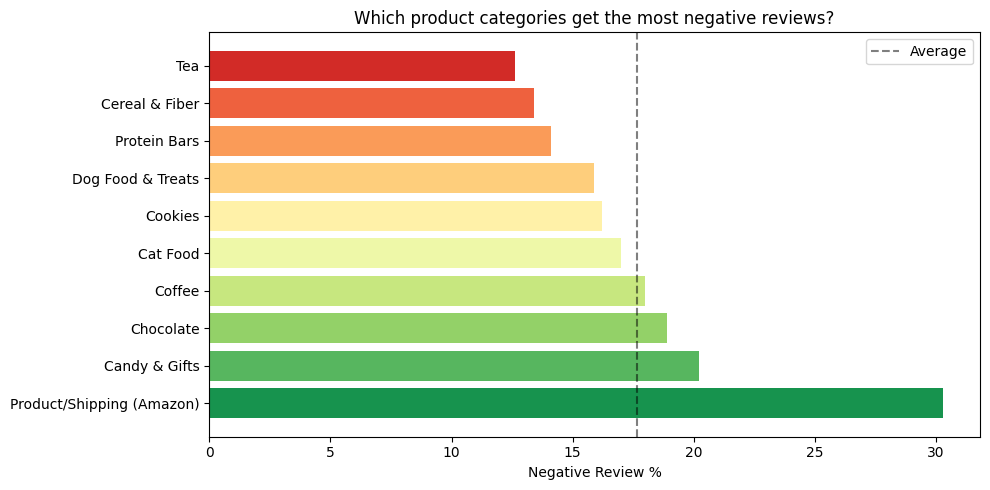

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out uncategorised
df_topics = df_sample[df_sample['topic'] != -1].copy()

# Calculate negative % per topic
topic_sentiment = df_topics.groupby('topic_label').agg(
    total      = ('pred_label', 'count'),
    positive   = ('pred_label', 'sum')
).reset_index()

topic_sentiment['negative_pct'] = (
    (topic_sentiment['total'] - topic_sentiment['positive']) 
    / topic_sentiment['total'] * 100
).round(1)

topic_sentiment = topic_sentiment.sort_values('negative_pct', ascending=False)
print(topic_sentiment[['topic_label','total','negative_pct']].to_string(index=False))

# Plot
plt.figure(figsize=(10, 5))
bars = plt.barh(
    topic_sentiment['topic_label'],
    topic_sentiment['negative_pct'],
    color=sns.color_palette("RdYlGn_r", len(topic_sentiment))
)
plt.xlabel('Negative Review %')
plt.title('Which product categories get the most negative reviews?')
plt.axvline(x=topic_sentiment['negative_pct'].mean(), 
            color='black', linestyle='--', alpha=0.5, label='Average')
plt.legend()
plt.tight_layout()
plt.savefig('topic_sentiment.png', dpi=150)
plt.show()

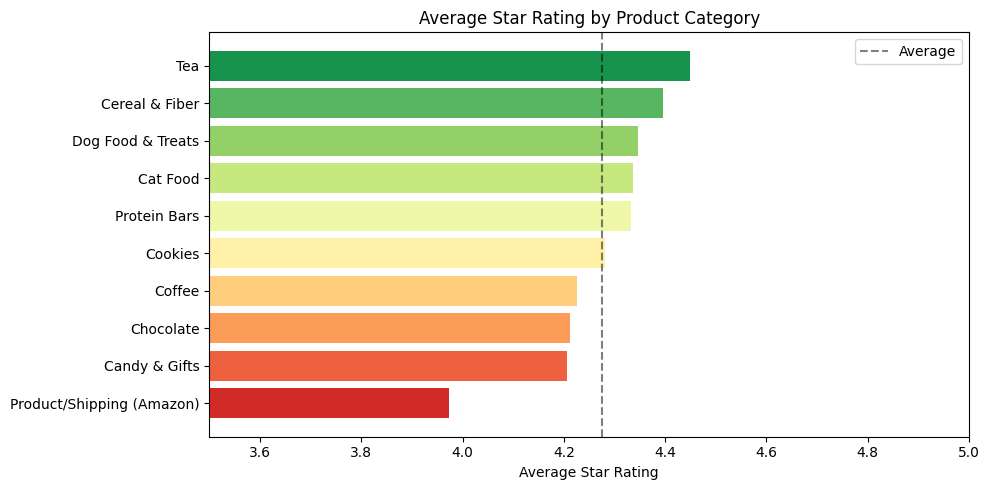

              topic_label  avg_score  total
Product/Shipping (Amazon)   3.973553   1399
            Candy & Gifts   4.205912    981
                Chocolate   4.211788   1001
                   Coffee   4.226266   5056
                  Cookies   4.280822    876
             Protein Bars   4.332966    907
                 Cat Food   4.335537   1210
        Dog Food & Treats   4.345690   3399
           Cereal & Fiber   4.395593    953
                      Tea   4.449481   3949


In [22]:
# Merge topic labels with original scores
topic_scores = df_topics.groupby('topic_label').agg(
    avg_score  = ('Score', 'mean'),
    total      = ('Score', 'count')
).reset_index().sort_values('avg_score')

plt.figure(figsize=(10, 5))
bars = plt.barh(
    topic_scores['topic_label'],
    topic_scores['avg_score'],
    color=sns.color_palette("RdYlGn", len(topic_scores))
)
plt.xlabel('Average Star Rating')
plt.title('Average Star Rating by Product Category')
plt.axvline(x=topic_scores['avg_score'].mean(),
            color='black', linestyle='--', alpha=0.5, label='Average')
plt.xlim(3.5, 5.0)
plt.legend()
plt.tight_layout()
plt.savefig('avg_rating_by_topic.png', dpi=150)
plt.show()

print(topic_scores[['topic_label','avg_score','total']].to_string(index=False))

In [23]:
# Find reviews where model got it wrong
df_errors = df_sample[
    (df_sample['pred_label'] != df_sample['label']) &
    (df_sample['topic'] != -1)
].copy()

print(f"Total misclassified: {len(df_errors)} / {len(df_sample)}")
print(f"Error rate: {len(df_errors)/len(df_sample)*100:.1f}%\n")

# Show 5 interesting misclassifications
print("=== False Positives (negative review predicted as positive) ===\n")
fp = df_errors[(df_errors['label']==0) & (df_errors['pred_label']==1)].head(3)
for _, row in fp.iterrows():
    print(f"Topic: {row['topic_label']} | Star: {row['Score']}")
    print(f"Text: {row['Text'][:200]}")
    print()

Total misclassified: 895 / 50000
Error rate: 1.8%

=== False Positives (negative review predicted as positive) ===

Topic: nan | Star: 1
Text: The product itself is excellent I have been buying it for years. It offers low carb high fibor and excellent taste.Your price is now 25% more then the retail price at our grocery store. I will no long

Topic: Coffee | Star: 1
Text: This was a great gift for my son & his wife - they have had many sleepless nights with a new baby. After New Years Day dinner we brewed one of the blends and had it with pie. The aroma and taste was e

Topic: Chocolate | Star: 1
Text: Well I can tell you this chocolate when purchased from a store, where it is refrigerated is awesome..!!  However, when purchasing it over the internet and having it shipped to your residence.. that's 



In [24]:
# Save predictions dataframe
df_sample.to_csv('/kaggle/working/predictions.csv', index=False)

# Save topic info
topic_model.get_topic_info().to_csv('/kaggle/working/topic_info.csv', index=False)

# Save topic sentiment summary
topic_sentiment.to_csv('/kaggle/working/topic_sentiment.csv', index=False)

print("Saved:")
print("  /kaggle/working/predictions.csv")
print("  /kaggle/working/topic_info.csv")
print("  /kaggle/working/topic_sentiment.csv")
print("  /kaggle/working/sentiment_model/")
print("\nAll outputs ready for download.")

Saved:
  /kaggle/working/predictions.csv
  /kaggle/working/topic_info.csv
  /kaggle/working/topic_sentiment.csv
  /kaggle/working/sentiment_model/

All outputs ready for download.


In [25]:
import shutil

shutil.make_archive('/kaggle/working/sentiment_model_export', 'zip', '/kaggle/working/sentiment_model')
print("Done — sentiment_model_export.zip is ready")

Done — sentiment_model_export.zip is ready


In [ ]:
from huggingface_hub import HfApi

api = HfApi()
api.upload_file(
    path_or_fileobj='/kaggle/working/sentiment_model/model.safetensors',
    path_in_repo='model.safetensors',
    repo_id='fionaghosh/amazon-food-review-sentiment',
    repo_type='model',
    token='your_huggingface_token_here'
)
print('Model uploaded!')

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Model uploaded!
